# Dinosaur Genera Dataset Exploration

## Summary 

In this notebook i want to explore the [dinosaur genera dataset](https://www.kaggle.com/datasets/canozensoy/dinosaur-genera-dataset/data).

### Questions

- Relation size diet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dinosaur_df = pd.read_csv('../Datasets/archive/dinoDatasetCSV.csv')
dinosaur_df.head()

,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,behavior_notes,first_discovered,fossil_location,notable_features,intelligence_level,source_link,row_index
0,Abelisaurus,Abelisaurus,Abel's lizard,Carnivore,7.0,1500.0,2.4,Bipedal,Late Cretaceous,Argentina,Large theropod,1985,Argentina,Short arms,Medium,https://en.wikipedia.org/wiki/Abelisaurus,0
1,Abrictosaurus,Abrictosaurus,Wakeful lizard,Herbivore,1.5,15.0,0.5,Bipedal,Early Jurassic,South Africa,Small herbivore,1974,South Africa,Unique teeth,Medium,https://en.wikipedia.org/wiki/Abrictosaurus,1
2,Abrosaurus,Abrosaurus,Delicate lizard,Herbivore,9.0,2000.0,4.5,Quadrupedal,Middle Jurassic,China,Delicate skull,1959,China,Delicate skull,Medium,https://en.wikipedia.org/wiki/Abrosaurus,2
3,Abydosaurus,Abydosaurus,Abydos lizard,Herbivore,18.0,30000.0,6.0,Quadrupedal,Early Cretaceous,USA,Basal sauropod,2010,USA,Complete skull,Medium,https://en.wikipedia.org/wiki/Abydosaurus,3
4,Acantholipan,Acantholipan,Spiny shield,Herbivore,5.0,2500.0,1.5,Quadrupedal,Late Cretaceous,Mexico,Armored nodosaur,2011,Mexico,Clubless armored tail,Medium,https://en.wikipedia.org/wiki/Acantholipan,4


In [2]:
print(dinosaur_df.info())
print("___________________________")
dinosaur_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   scientific_name     1542 non-null   object 
 1   common_name         1542 non-null   object 
 2   meaning             1542 non-null   object 
 3   diet                1542 non-null   object 
 4   length_m            1503 non-null   float64
 5   weight_kg           1504 non-null   float64
 6   height_m            1510 non-null   float64
 7   locomotion          1542 non-null   object 
 8   geological_period   1542 non-null   object 
 9   lived_in            1542 non-null   object 
 10  behavior_notes      1542 non-null   object 
 11  first_discovered    1542 non-null   object 
 12  fossil_location     1542 non-null   object 
 13  notable_features    1542 non-null   object 
 14  intelligence_level  1542 non-null   object 
 15  source_link         1542 non-null   object 
 16  row_in

,length_m,weight_kg,height_m,row_index
count,1503.000000,1504.000000,1510.000000,1542.000000
mean,6.691397,3827.900625,2.377947,770.500000
std,5.493007,7510.800693,1.685147,445.281372
min,0.300000,0.100000,0.100000,0.000000
25%,2.500000,100.000000,1.000000,385.250000
50%,6.000000,1500.000000,2.000000,770.500000
75%,9.000000,3500.000000,3.000000,1155.750000
max,37.000000,75000.000000,12.000000,1541.000000


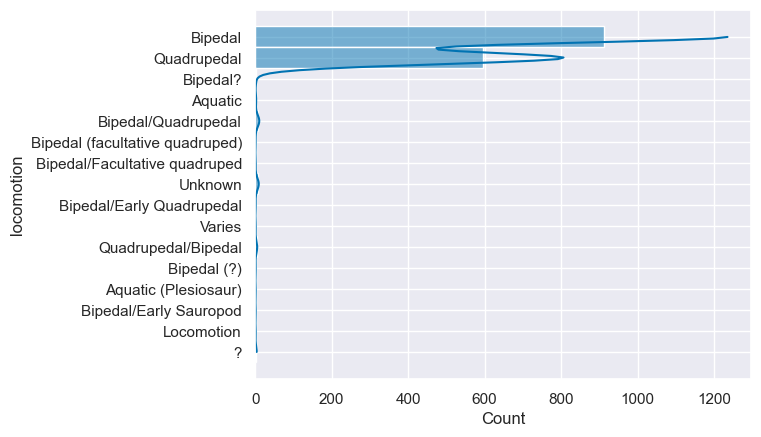

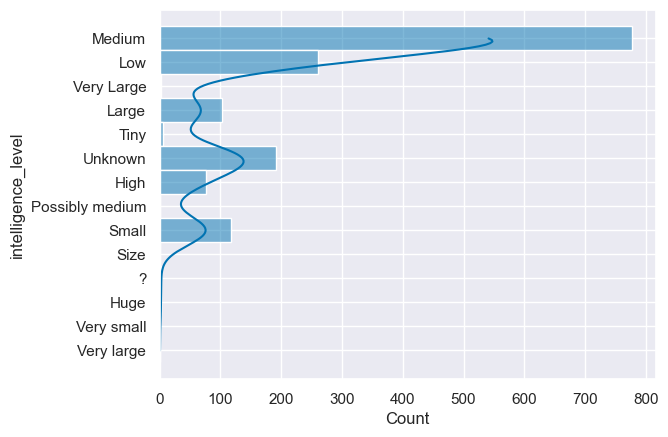

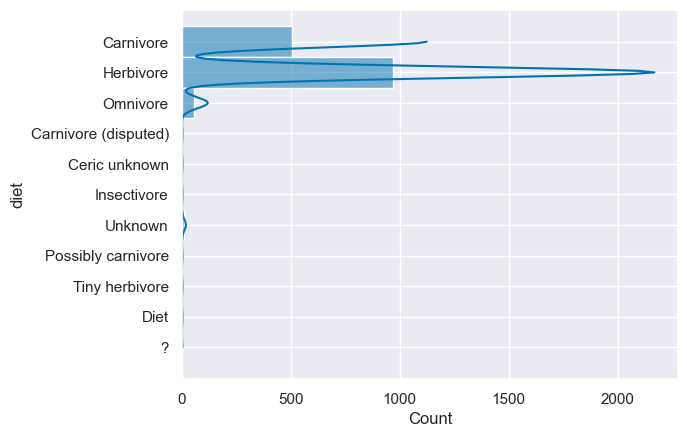

In [3]:
list=["locomotion","intelligence_level","diet"]

#fig, axes = plt.subplots(3, 2, figsize=(16, 10))
plt.tight_layout(w_pad=10)


for feature in list:
    sns.set_theme(font_scale=1,style="darkgrid")
    sns.set_palette("colorblind")
    g=sns.histplot( y=dinosaur_df[feature],kde=True)
    #plt.title("Distribution of Diets")
    plt.show()


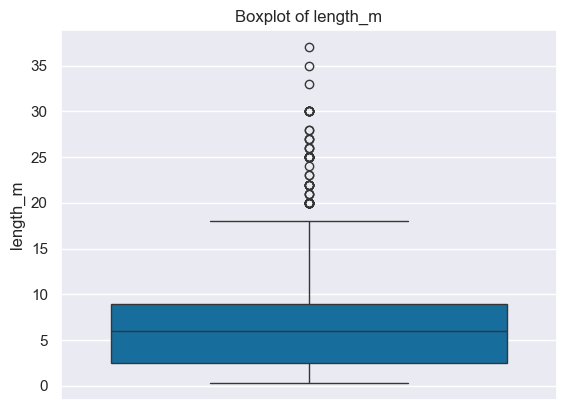

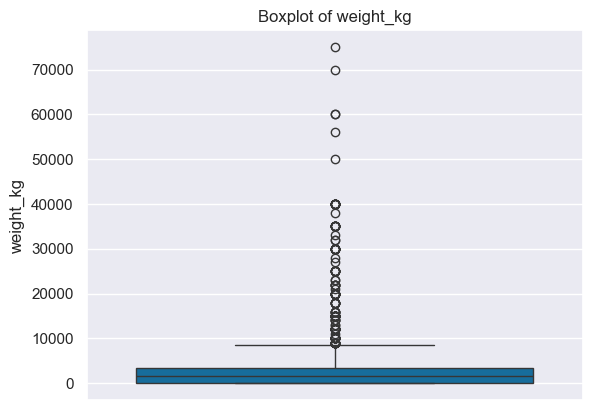

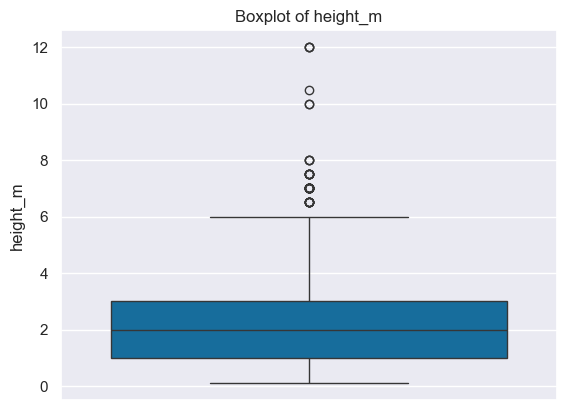

In [4]:
# Looking for outliers in numeric columns
list=["length_m","weight_kg","height_m"]

for x in list:
    plt.title(f"Boxplot of {x}")
    sns.boxplot(data=dinosaur_df,y=x)
    plt.show()

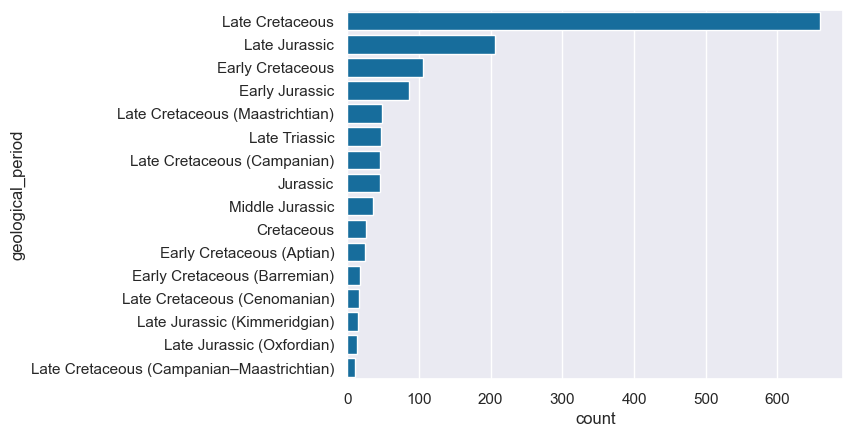

In [5]:
# Geololigal periods over with over 10 occurences
s=pd.DataFrame(dinosaur_df.value_counts("geological_period"))
s2 = s[s["count"]>10]
sns.barplot(y=s2.index,x=s2["count"])
plt.show()

## Amount of Discoveries through the years

For further investigations i want to include the time when the fossils have been found. Therefore I compresse the time in to decades.

In [6]:
#dinosaur_df.value_counts("first_discovered",ascending=True)
#x = np.floor(dinosaur_df["first_discovered"]/10)
dinosaur_df["cleaned_time"] = pd.to_numeric(dinosaur_df["first_discovered"],errors="coerce")
df = dinosaur_df.dropna(subset=["cleaned_time"])
df["decade"] = np.floor(df["cleaned_time"]/10)*10
df["decade"] = df["decade"].astype("int")


C:\Users\kyild\AppData\Local\Temp\ipykernel_13580\3883831955.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["decade"] = np.floor(df["cleaned_time"]/10)*10
C:\Users\kyild\AppData\Local\Temp\ipykernel_13580\3883831955.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["decade"] = df["decade"].astype("int")


In [7]:
time_df = pd.DataFrame(df["decade"].value_counts())

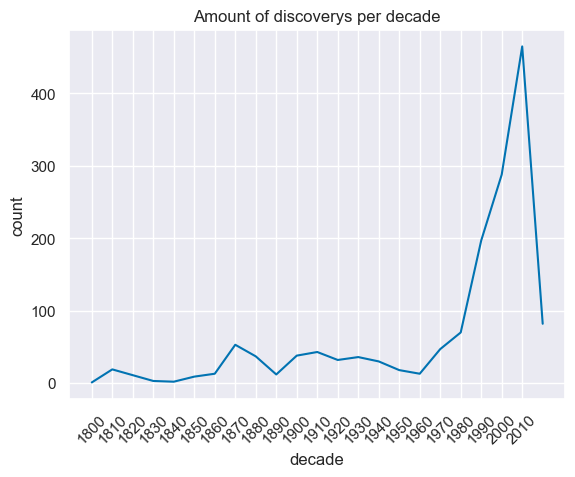

In [8]:
#g= sns.lineplot(x=df["decade"].value_counts().index,y=df["decade"].value_counts().values)
g= sns.lineplot(data=time_df,x="decade",y="count")
plt.xticks(np.arange(min(time_df.index),max(time_df.index),10))
plt.title("Amount of discoverys per decade")
plt.xticks(rotation=45)
plt.show()

## Relation between size and diet

For this section I want to visualize the relation between diet and Size of the dinosaurs.

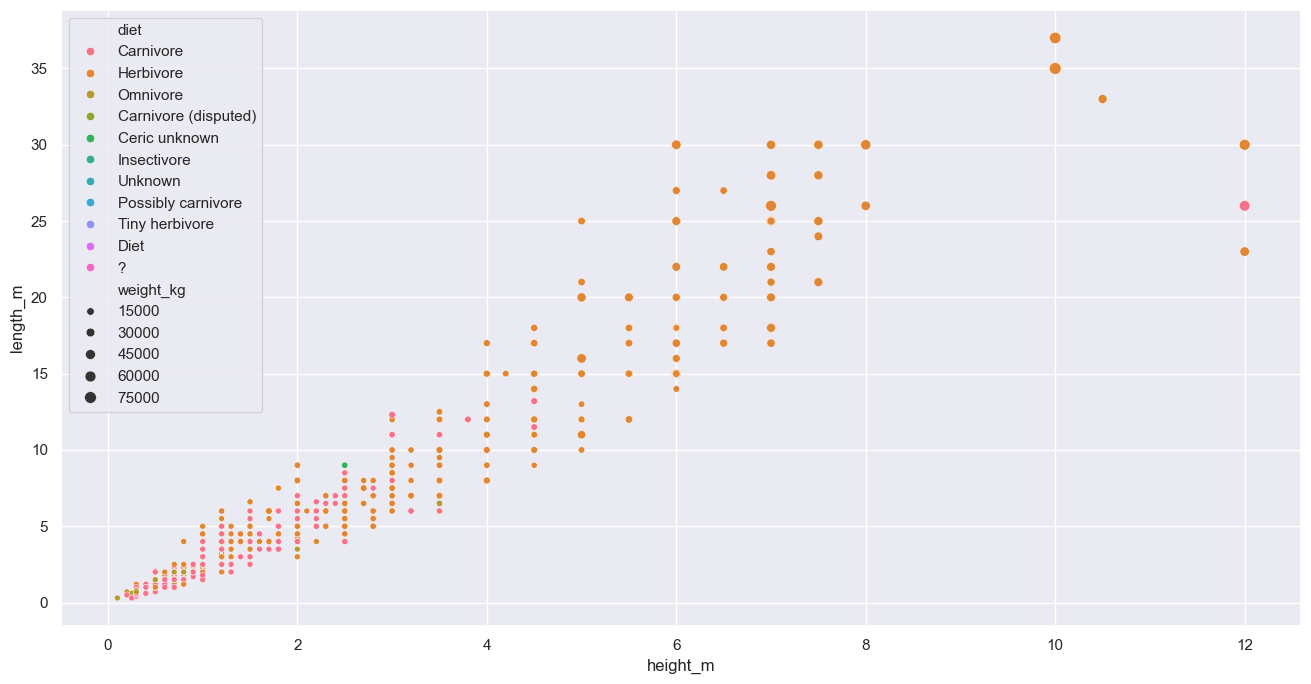

In [16]:
fig,ax= plt.subplots(figsize=(16,8))
sns.set_context('poster')
sns.set_theme(font_scale=1)
sns.scatterplot(data=dinosaur_df,x="height_m",y="length_m",hue="diet",size="weight_kg")
plt.show()

As we can see the bigger sized dino's where mostly herbivores with one exception. Lets find out which one is the exception too the rule.

In [25]:
diet_df=dinosaur_df.groupby("diet").agg("max")
diet_df.loc["Carnivore"]

scientific_name                                        Zupaysaurus
common_name                                   Zupaysaurus rougieri
meaning                                               western claw
length_m                                                      26.0
weight_kg                                                  56000.0
height_m                                                      12.0
locomotion                                             Quadrupedal
geological_period                                Triassic (Norian)
lived_in                                                Uzbekistan
behavior_notes        Unusual dromaeosaur with double sickle claws
first_discovered                                              2022
fossil_location                                 Ömnögovi, Mongolia
notable_features      Well-preserved feathers; four-winged anatomy
intelligence_level                                      Very small
source_link              https://en.wikipedia.org/wiki/Zupaysa

After a quick research there seems to be a an error in the dataset with this one so lets drop it.

In [155]:
df2=dinosaur_df[dinosaur_df["scientific_name"]=="Zupaysaurus"].drop(dinosaur_df[dinosaur_df["scientific_name"]=="Zupaysaurus"].index,axis=0)
df2[dinosaur_df["scientific_name"]=="sadda"]
#removed succesfully

C:\Users\kyild\AppData\Local\Temp\ipykernel_13580\501743193.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2[dinosaur_df["scientific_name"]=="sadda"]


,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,behavior_notes,first_discovered,fossil_location,notable_features,intelligence_level,source_link,row_index,cleaned_time


## Fossil Locations

Where have the most fossils been discovered?

In [317]:
# We filter for everthing above 16 for better visualisation
fossil_locations = dinosaur_df.groupby(by="fossil_location").size().sort_values(ascending=False)
fossil_locations_filtered= fossil_locations[fossil_locations.apply(lambda x:x>10)]
fossil_locations


fossil_location
China                              238
USA                                238
Argentina                          187
Canada                              55
Mongolia                            46
                                  ... 
Adamantina Formation, São Paulo      1
Zambia                               1
Zhejiang, China                      1
?                                    1
Ömnögovi, Mongolia                   1
Length: 351, dtype: int64

In [321]:
fossil_locations = df.groupby(by=["fossil_location","decade"],as_index=False).agg('size').sort_values(by="size",ascending=False)
fossil_locations["total_size"] = (
    fossil_locations
    .groupby("fossil_location")["size"]
    .transform("sum")
)
#fossil_locations_filtered#.groupby("fossil_location").sum()
fossil_locations_filtered = fossil_locations[fossil_locations["total_size"]>10]
fossil_locations_filtered

,fossil_location,decade,size,total_size
108,China,2010,88,237
107,China,2000,82,237
523,USA,2010,64,238
30,Argentina,2010,60,187
28,Argentina,1990,56,187
...,...,...,...,...
78,Canada,1920,1,55
79,Canada,1940,1,55
80,Canada,1950,1,55
83,Canada,2020,1,55


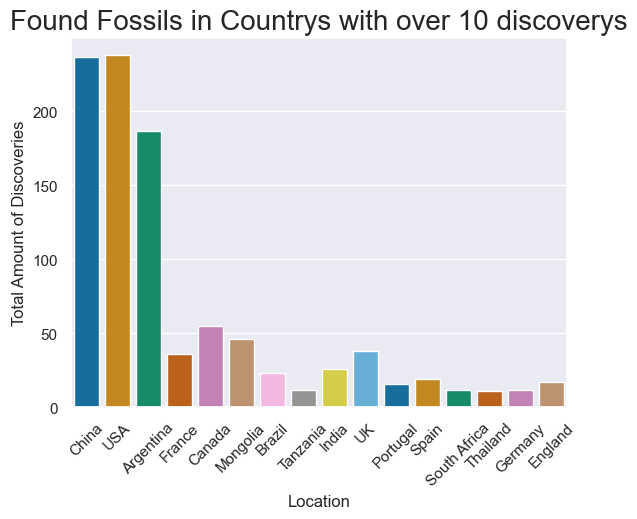

In [338]:
g=sns.barplot(data=fossil_locations_filtered,x="fossil_location",y="total_size",palette="colorblind",hue="fossil_location",errorbar=None)
sns.set_theme("notebook",font_scale=0.5)
plt.xlabel("Location")
plt.ylabel("Total Amount of Discoveries")
plt.title("Found Fossils in Countrys with over 10 discoverys",fontdict={"fontsize":20})
plt.xticks(rotation=45)
plt.show()